In [1]:
import math
import random
import gymnasium as gym
import numpy as np
from stable_baselines3.common.env_checker import check_env
print("No problems")

No problems


In [3]:
#Onto the pricing game now
#For ease of writing, we scale all the payoffs by a factor of k (equivalently, scaling up all prices by a factor of k)
#basic demand model with symmetric agents
#Lower price gets full demand, 50-50 in case of ties

def build_payoff_matrix_row_player(k):
    #Set of prices = {1,2,..,k}

    #Changing the prices to {1,2,,,k}
    matrix = []
    for i in range(k):
        row = []
        for j in range(k):
            if i < j:
                row.append(i+1)
            elif i > j:
                row.append(0)
            else:
                row.append((i+1)/2)
        matrix.append(row)
    return np.array(matrix)

def build_payoff_matrix_column_player(k):
    #Set of prices = {0,1,2,..,k}

    #Changing the prices to {1,2,,,k}
    matrix = []
    for i in range(k):
        row = []
        for j in range(k):
            if i < j:
                row.append(0)
            elif i > j:
                row.append(j+1)
            else:
                row.append((j+1)/2)
        matrix.append(row)
    return np.array(matrix)


In [4]:
k_test = 10
print(build_payoff_matrix_row_player(k_test))
print(build_payoff_matrix_column_player(k_test))

[[0.5 1.  1.  1.  1.  1.  1.  1.  1.  1. ]
 [0.  1.  2.  2.  2.  2.  2.  2.  2.  2. ]
 [0.  0.  1.5 3.  3.  3.  3.  3.  3.  3. ]
 [0.  0.  0.  2.  4.  4.  4.  4.  4.  4. ]
 [0.  0.  0.  0.  2.5 5.  5.  5.  5.  5. ]
 [0.  0.  0.  0.  0.  3.  6.  6.  6.  6. ]
 [0.  0.  0.  0.  0.  0.  3.5 7.  7.  7. ]
 [0.  0.  0.  0.  0.  0.  0.  4.  8.  8. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  4.5 9. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  5. ]]
[[0.5 0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.  1.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.  2.  1.5 0.  0.  0.  0.  0.  0.  0. ]
 [1.  2.  3.  2.  0.  0.  0.  0.  0.  0. ]
 [1.  2.  3.  4.  2.5 0.  0.  0.  0.  0. ]
 [1.  2.  3.  4.  5.  3.  0.  0.  0.  0. ]
 [1.  2.  3.  4.  5.  6.  3.5 0.  0.  0. ]
 [1.  2.  3.  4.  5.  6.  7.  4.  0.  0. ]
 [1.  2.  3.  4.  5.  6.  7.  8.  4.5 0. ]
 [1.  2.  3.  4.  5.  6.  7.  8.  9.  5. ]]


In [6]:
#Code for the RL environment defined by FTL

import numpy as np
import gymnasium as gym
from gymnasium import spaces


#row player -- RL
#col player --  FTL

class PricingGameEnv(gym.Env):
    def __init__(self, k, T):
        """
        k: Number of price options (e.g., 100)
        T: Number of rounds in each trajectory (episode)
        """
        super(PricingGameEnv, self).__init__()

        self.k = k  # Number of available prices
        self.T = T  # Number of rounds per trajectory
        self.current_round = 0  # Track rounds within an episode

        # Define action and observation spaces
        self.action_space = spaces.Discrete(k)  
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(k,), dtype=np.float32)

        # Initialize payoff matrices
        self.row_player_payoff = build_payoff_matrix_row_player(k)
        self.column_player_payoff = build_payoff_matrix_column_player(k)

        # Initialize FTL opponent's memory
        self.ftl_cumulative_rewards = np.zeros(k)

    def step(self, action):
        """Execute one step (one round of the pricing game)."""
        self.current_round += 1  # Increment round counter

        # Compute rewards for all actions (counterfactual updates)
        rewards_for_all_actions = self.column_player_payoff[action, :]  # FTL's payoffs for each col action (the row action is fixed to be the input argument action)

        

        # FTL chooses the best action
        best_actions = np.where(self.ftl_cumulative_rewards == np.max(self.ftl_cumulative_rewards))[0]
        ftl_action = np.random.choice(best_actions)

        # Update cumulative rewards for *all* actions after the FTL action is chosen
        self.ftl_cumulative_rewards += rewards_for_all_actions

        # Compute rewards
        agent_reward = self.row_player_payoff[action, ftl_action]


        # Observation is the cumulative rewards of the FTL opponent
        observation = self.ftl_cumulative_rewards.copy()

        # Check if the trajectory (episode) has ended
        terminated = self.current_round >= self.T  # Ends after T rounds
        truncated = False  # No artificial time constraints

        # If trajectory ends, reset the environment
        if terminated:
            self.current_round = 0  # Reset round counter
            self.ftl_cumulative_rewards = np.zeros(self.k)  # Reset FTL memory

        return observation, agent_reward, terminated, truncated, {"ftl_action": ftl_action}

    def reset(self, seed=None, options=None):
        """Reset the environment for a new trajectory."""
        super().reset(seed=seed)
        self.current_round = 0
        self.ftl_cumulative_rewards = np.zeros(self.k)  # Reset FTL opponent
        return self.ftl_cumulative_rewards.copy(), {}


In [7]:
from stable_baselines3 import PPO

# Set k (number of price options), T (rounds per trajectory), Q (total PPO training steps)
k = 20
T = 5000  # Number of rounds in each trajectory
Q = 100000  # Total PPO training steps

# Create the environment
env = PricingGameEnv(k, T)

# Train PPO for Q steps
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=Q)  # Q controls the total RL training

# Save the trained model
model.save("pricing_game_ppo")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 1033 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 466         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.019183572 |
|    clip_fraction        | 0.429       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.98       |
|    explained_variance   | 0.00125     |
|    learning_rate        | 0.0003      |
|    loss                 | 677         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0508     |
|    value_loss         

RL Agent Action Frequencies:
Action 0: 50000 times

FTL Opponent Action Frequencies:
Action 0: 49993 times
Action 2: 1 times
Action 5: 2 times
Action 7: 1 times
Action 14: 1 times
Action 17: 2 times

Normalized Reward per Trajectory (per round):
Trajectory 1: Average Reward = 0.5001
Trajectory 2: Average Reward = 0.5001
Trajectory 3: Average Reward = 0.5
Trajectory 4: Average Reward = 0.5
Trajectory 5: Average Reward = 0.5001
Trajectory 6: Average Reward = 0.5001
Trajectory 7: Average Reward = 0.5001
Trajectory 8: Average Reward = 0.5001
Trajectory 9: Average Reward = 0.5001
Trajectory 10: Average Reward = 0.5

Overall Average Reward per Trajectory (per round): 0.5000699999999999


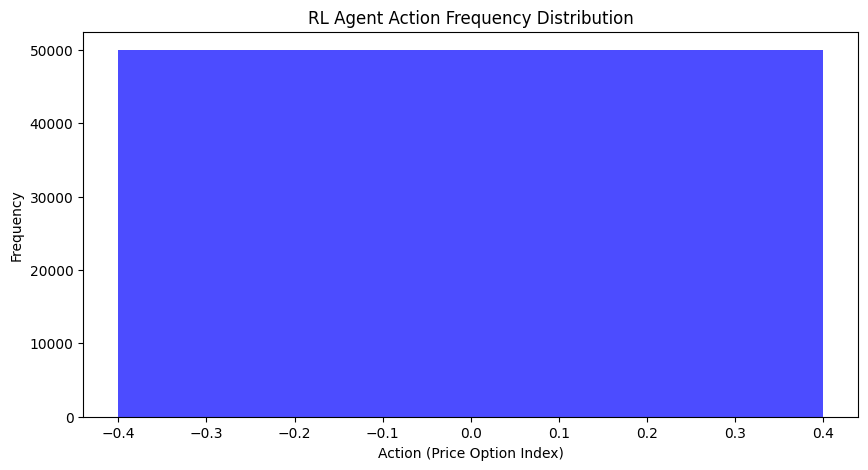

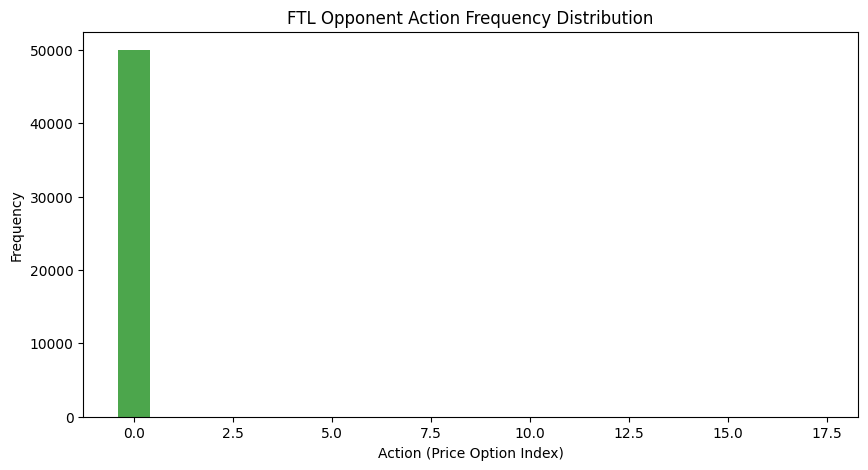

In [8]:
import collections
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# Load the trained PPO model
model = PPO.load("pricing_game_ppo")

# Ensure that your environment 'env' is already defined, along with T and k.
# For example:
# k = 100
# T = 1000
# env = PricingGameEnv(k, T)

num_evaluation_trajectories = 10  # Number of trajectories to evaluate

agent_actions_all = []
ftl_actions_all = []
trajectory_rewards = []  # To store normalized reward for each trajectory

# Evaluate the model over a number of trajectories
for episode in range(num_evaluation_trajectories):
    obs, _ = env.reset()
    total_reward = 0  # Reset total reward for this trajectory
    for _ in range(T):  # Each trajectory lasts T rounds
        action, _states = model.predict(obs, deterministic=True)
        # Convert action to a hashable type (scalar)
        agent_action = action.item() if hasattr(action, "item") else action
        agent_actions_all.append(agent_action)
        
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        
        # Convert the FTL action to a hashable type
        ftl_action = info["ftl_action"].item() if hasattr(info["ftl_action"], "item") else info["ftl_action"]
        ftl_actions_all.append(ftl_action)
    # Normalize reward by T to get per-round reward
    trajectory_rewards.append(total_reward / T)

# Compute frequency counts using Counter
agent_counter = collections.Counter(agent_actions_all)
ftl_counter = collections.Counter(ftl_actions_all)

# Print out action frequencies
print("RL Agent Action Frequencies:")
for action, count in sorted(agent_counter.items()):
    print(f"Action {action}: {count} times")

print("\nFTL Opponent Action Frequencies:")
for action, count in sorted(ftl_counter.items()):
    print(f"Action {action}: {count} times")

# Print normalized rewards for each trajectory
print("\nNormalized Reward per Trajectory (per round):")
for i, reward in enumerate(trajectory_rewards, start=1):
    print(f"Trajectory {i}: Average Reward = {reward}")

# Calculate and print average normalized reward across trajectories
average_reward = sum(trajectory_rewards) / num_evaluation_trajectories
print(f"\nOverall Average Reward per Trajectory (per round): {average_reward}")

# Plot histograms for the action distributions
plt.figure(figsize=(10, 5))
plt.bar(agent_counter.keys(), agent_counter.values(), color='blue', alpha=0.7)
plt.title("RL Agent Action Frequency Distribution")
plt.xlabel("Action (Price Option Index)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(ftl_counter.keys(), ftl_counter.values(), color='green', alpha=0.7)
plt.title("FTL Opponent Action Frequency Distribution")
plt.xlabel("Action (Price Option Index)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import os

# Set k, T, Q
k = 20
T = 1000  # Shorter episode length
Q = 2_000_000 # Increased training time

# Create the environment function
def make_env():
    return PricingGameEnv(k, T)

# Create a vectorized environment
vec_env = DummyVecEnv([make_env])

# Wrap with VecNormalize
env_save_path = "pricing_game_vecnormalize.pkl"
if os.path.exists(env_save_path):
    print("Loading existing VecNormalize statistics.")
    env = VecNormalize.load(env_save_path, vec_env)
    env.reset() # Important: Reset env after loading stats
else:
    print("Creating new VecNormalize statistics.")
    env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.)

print("Training PPO...")
# Use n_steps=T and potentially increase ent_coef
model = PPO("MlpPolicy", env, verbose=1, n_steps=T, batch_size=min(T, 256), ent_coef=0.01) # Adjust batch_size if T is large
model.learn(total_timesteps=Q, log_interval=10) # Log more frequently initially

# Save the model AND the normalization stats
model_save_path = "pricing_game_ppo_normalized"
print(f"Saving model to {model_save_path}")
model.save(model_save_path)
print(f"Saving VecNormalize stats to {env_save_path}")
env.save(env_save_path)
print("Training finished.")

# --- Evaluation (in the same script or a new one) ---
print("\nEvaluating trained model...")

# Load the normalization stats FIRST
eval_vec_env = DummyVecEnv([make_env]) # Create a non-normalized env instance
eval_env = VecNormalize.load(env_save_path, eval_vec_env)
eval_env.training = False # Set training to False

# Load the model, passing the now normalized environment
model = PPO.load(model_save_path, env=eval_env)

num_evaluation_trajectories = 10
agent_actions_all = []
ftl_actions_all = []
trajectory_rewards = []

for episode in range(num_evaluation_trajectories):
    obs = eval_env.reset() # Use the normalized env for reset and step
    total_reward = 0
    agent_actions_ep = []
    ftl_actions_ep = []
    for _ in range(T):
        action, _states = model.predict(obs, deterministic=True)
        # Note: Action from VecEnv might be an array, handle appropriately
        agent_action = action[0].item() if isinstance(action, (np.ndarray, list)) else action.item()
        agent_actions_ep.append(agent_action)

        obs, reward, terminated, truncated, info = eval_env.step(action)

        # Reward might be an array from VecEnv
        current_reward = reward[0] if isinstance(reward, (np.ndarray, list)) else reward
        total_reward += current_reward

        # Info is usually a list of dicts for VecEnv
        current_info = info[0] if isinstance(info, list) else info
        ftl_action = current_info["ftl_action"].item() if hasattr(current_info["ftl_action"], "item") else current_info["ftl_action"]
        ftl_actions_ep.append(ftl_action)

        # Handle termination/truncation if using VecEnv
        done = (terminated[0] if isinstance(terminated, (np.ndarray, list)) else terminated) or \
               (truncated[0] if isinstance(truncated, (np.ndarray, list)) else truncated)
        if done:
           # This shouldn't happen if T is fixed, but good practice
           break

    agent_actions_all.extend(agent_actions_ep)
    ftl_actions_all.extend(ftl_actions_ep)
    trajectory_rewards.append(total_reward / T)

# ... (rest of your plotting and printing code - should work fine) ...
# Compute frequency counts using Counter
agent_counter = collections.Counter(agent_actions_all)
ftl_counter = collections.Counter(ftl_actions_all)

# Print out action frequencies
print("RL Agent Action Frequencies:")
for action, count in sorted(agent_counter.items()):
    print(f"Action {action}: {count} times")

print("\nFTL Opponent Action Frequencies:")
for action, count in sorted(ftl_counter.items()):
    print(f"Action {action}: {count} times")

# Print normalized rewards for each trajectory
print("\nNormalized Reward per Trajectory (per round):")
for i, reward in enumerate(trajectory_rewards, start=1):
    print(f"Trajectory {i}: Average Reward = {reward}")

# Calculate and print average normalized reward across trajectories
average_reward = sum(trajectory_rewards) / num_evaluation_trajectories
print(f"\nOverall Average Reward per Trajectory (per round): {average_reward}")

# Plot histograms for the action distributions
plt.figure(figsize=(10, 5))
plt.bar(agent_counter.keys(), agent_counter.values(), color='blue', alpha=0.7)
plt.title("RL Agent Action Frequency Distribution")
plt.xlabel("Action (Price Option Index)")
plt.ylabel("Frequency")
plt.xticks(range(k)) # Ensure all actions are shown if needed
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(ftl_counter.keys(), ftl_counter.values(), color='green', alpha=0.7)
plt.title("FTL Opponent Action Frequency Distribution")
plt.xlabel("Action (Price Option Index)")
plt.ylabel("Frequency")
plt.xticks(range(k)) # Ensure all actions are shown if needed
plt.show()